In [18]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

In [19]:
plt.rcParams.update({
    # "figure.figsize": (3.5, 2.4),
    "font.family": "serif",
    "font.serif": ["Times New Roman", "TeX Gyre Termes", "STIXGeneral"],
    "mathtext.fontset": "stix",
    "font.size": 12,
})

In [20]:
def plot_flat_timeseries(npz_path: str | Path):
    """Return a figure showing velocity tracking and fault probabilities."""
    data = np.load(npz_path)
    time = data["time_s"]
    command = data["command_xy_mps"]
    measured = data["measured_xy_mps"]
    probability = data["fault_probability"]
    joint_names = data["joint_names"].astype(str)
    fault_joint = str(data["fault_joint"])
    fault_time = float(data["fault_time_s"])

    plot_names = ("command", "fault")
    figure, axes = plt.subplots(len(plot_names), 1, figsize=(6, 4), sharex=True)
    for i, name in enumerate(plot_names):
        if name == "command":
            axes[i].plot(time, command[:, 0], "k--", label=r"command $v_x$")
            axes[i].plot(time, measured[:, 0], label=r"measured $v_x$")
            axes[i].plot(time, measured[:, 1], label=r"measured $v_y$")
            axes[i].set_ylabel("Velocity (m/s)")
            axes[i].legend(
                ncol=1,
                loc="center left",
                fontsize=12,
                )
        elif name == "ate":
            axes[i].plot(time, data["xy_tracking_error_mps"], label="instantaneous error")
            axes[i].plot(time, data["cumulative_ate_xy_mps"], label="cumulative ATE")
            axes[i].set_ylabel(r"$xy$ error (m/s)")
            axes[i].legend()
        elif name == "fault":
            for joint_id, joint_name in enumerate(joint_names):
                is_fault = joint_name == fault_joint
                axes[i].plot(
                    time,
                    probability[:, joint_id],
                    linewidth=2.5 if is_fault else 0.9,
                    alpha=1.0 if is_fault else 0.45,
                    label=joint_name,
                )
            axes[i].set_ylabel("Fault probability")
            axes[i].set_xlabel("Time (s)")
            axes[i].set_ylim(-0.02, 1.02)
            # axes[i].legend(ncol=3, fontsize=8)
            axes[i].legend(
                handles=[axes[i].lines[3]],
                labels=["RR hip"],
                loc="center left",
                fontsize=12,
                frameon=False,
            )

    for axis in axes:
        axis.axvline(fault_time, color="red", linestyle="--", label="fault onset")
        axis.grid(alpha=0.25)

    # figure.suptitle(f"Flat-ground recovery: {fault_joint}")
    figure.tight_layout()
    return figure, axes

In [21]:
npz_path = (
    "/home/qdinh/summerschool_ws_ws/quadlocofault/logs/evaluation/flat_recovery_equivgcnmlp_4000epochs_seed2_rr_hip/timeseries/equivgcnmlp_RR_hip_joint_seed_0_fault_0.0.npz"
)

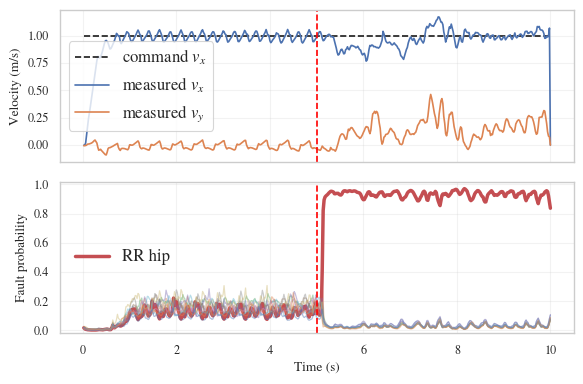

In [22]:
fig, _ = plot_flat_timeseries(npz_path)
plt.savefig("../media/rr_hip_flat.pdf", format="pdf")
plt.show()

In [23]:
def plot_foot_contacts(npz_path: str | Path):
    """Return a step plot of the per-foot contact states."""
    data = np.load(npz_path)
    time = data["time_s"]
    contacts = data["foot_contact"]
    foot_names = data["foot_names"].astype(str)
    fault_joint = str(data["fault_joint"])
    fault_time = float(data["fault_time_s"])

    figure, axis = plt.subplots(figsize=(10, 3.8), constrained_layout=True)
    for foot_id, foot_name in enumerate(foot_names):
        axis.step(
            time,
            contacts[:, foot_id] + foot_id,
            where="post",
            label=foot_name,
        )
    axis.axvline(fault_time, color="red", linestyle="--", label="fault onset")
    axis.set_yticks(range(len(foot_names)), foot_names)
    axis.set_xlabel("Time (s)")
    axis.set_ylabel("Foot contact")
    axis.set_title(f"Flat-ground recovery contacts: {fault_joint}")
    axis.grid(alpha=0.25)
    axis.legend(loc="upper right")
    return figure, axis

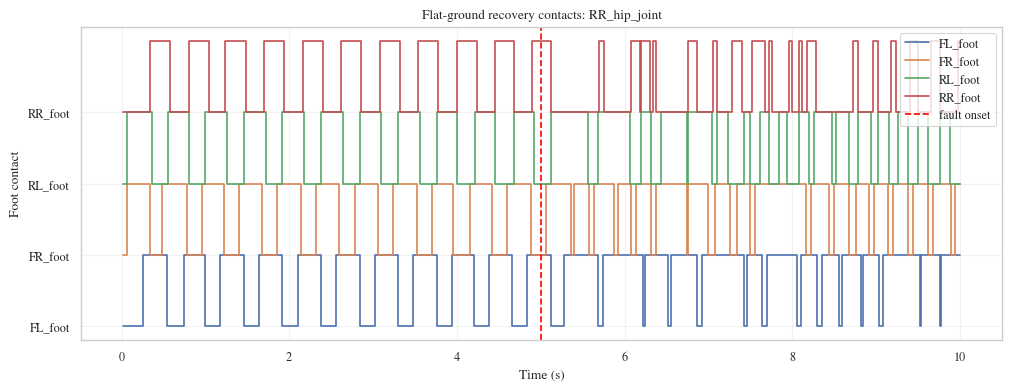

In [24]:
# Foot-contact states
fig_equiv_contacts, ax_equiv_contacts = plot_foot_contacts(npz_path)

In [25]:
npz_path = Path(
    "/home/qdinh/summerschool_ws_ws/quadlocofault/logs/evaluation/"
    "benchmark_v6_4000epochs_equivgcnmlp_seed2_latents/latents/"
    "equivgcnmlp_step_50_seed_0_fault_0.0.npz"
)

data = np.load(npz_path)

X = data["fused_latent"]
labels = data["fault_labels"]
joint_names = data["joint_names"].astype(str)
healthy_class = int(data["healthy_class"])

print("Latent shape:", X.shape)
print("Joint names:", joint_names)
print("Class counts:", np.bincount(labels, minlength=healthy_class + 1))

Latent shape: (3600, 16)
Joint names: ['FL_hip_joint' 'FR_hip_joint' 'RL_hip_joint' 'RR_hip_joint'
 'FL_thigh_joint' 'FR_thigh_joint' 'RL_thigh_joint' 'RR_thigh_joint'
 'FL_calf_joint' 'FR_calf_joint' 'RL_calf_joint' 'RR_calf_joint']
Class counts: [300 300 300 300 300 300 300 300 300 300 300 300   0]


In [26]:
from sklearn.manifold import TSNE

In [27]:
embedding = TSNE(
    n_components=2,
    perplexity=100,
    init="pca",
    learning_rate="auto",
    random_state=0,
).fit_transform(X)

print("Embedding shape:", embedding.shape)

Embedding shape: (3600, 2)


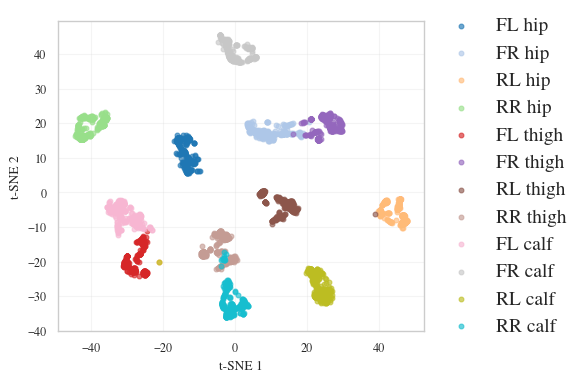

In [32]:
fig, ax = plt.subplots(figsize=(6, 4.0))
cmap = plt.get_cmap("tab20", healthy_class + 1)

for class_id in np.unique(labels):
    mask = labels == class_id
    class_name = (
        "Healthy"
        if class_id == healthy_class
        else joint_names[class_id].replace("_joint", "").replace("_", " ")
    )

    ax.scatter(
        embedding[mask, 0],
        embedding[mask, 1],
        s=12,
        alpha=0.65,
        color=cmap(class_id),
        label=f"{class_name}",
        rasterized=True,
    )

ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    frameon=False,
    ncol=1,
    fontsize=12,
)
ax.grid(alpha=0.2)

fig.tight_layout()
fig.savefig("../media/equivgcnmlp_fused_latent_tsne.pdf", bbox_inches="tight")
plt.show()